# Algorithm for triangular inverse on cube unit

In [ ]:
import numpy as np
from numpy.linalg import inv
 
N_VALUES = [32, 64, 128]
INPUT_DTYPE = np.float16

def is_power_of_2(c):
    return (c != 0) and (c & (c-1) == 0)
    
 
def strict_lower(c=4, seed=0):
    return np.tril(np.random.rand(c, c), k=-1)
    # L = np.tril(0.5*np.ones((c, c)))
    # L = L - 0.5*np.identity(c)
    # return L

def inv_trick(A, refinement_steps=0, max_iters=0):
    """
    Compute (I + A)^{-1} without explicit inversion
    """
    assert A.ndim == 2 and A.shape[0] == A.shape[1]
    c = A.shape[0]
    if max_iters == 0:
        max_iters = int(np.log2(c))
    assert is_power_of_2(c) and c >= 4
    I = np.eye(c).astype(INPUT_DTYPE)
    X = I - A
    Y = A
    for _ in range(max_iters):
        Y = Y @ Y
        X = X + X @ Y
    for _ in range(refinement_steps):
        R = I - (I + A) @ X
        X = X + X @ R
    return X
 
def inv_recurse(A):
    # Reference: Section 3.1 in Demmel et al https://arxiv.org/pdf/math/0612264
    n = A.shape[0]
    A_inv = np.zeros(A.shape, dtype=INPUT_DTYPE)
    A11 = A[0:n//2,0:n//2]
    A22 = A[n//2:,n//2:]
    A21 = A[n//2:,0:n//2]
    if n//2 > 4:
        A_inv[0:n//2,0:n//2] = inv_recurse(A11)
        A_inv[n//2:,n//2:] = inv_recurse(A22)
    else:
        A_inv[0:n//2,0:n//2] = inv_trick(A11)
        A_inv[n//2:,n//2:] = inv_trick(A22)
    A_inv[n//2:,0:n//2] = - A_inv[n//2:,n//2:] @ A21 @ A_inv[0:n//2,0:n//2] 
    return A_inv

def even_blocks(A, b):
    n = A.shape[0]
    B = np.zeros((n,n), dtype=INPUT_DTYPE)
    for idx in range(0, n, 2*b):
        B[idx:idx+b,idx:idx+b] = A[idx:idx+b,idx:idx+b]
    return B
def odd_blocks(A, b):
    n = A.shape[0]
    B = np.zeros((n,n), dtype=INPUT_DTYPE)
    for idx in range(b, n, 2*b):
        B[idx:idx+b,idx:idx+b] = A[idx:idx+b,idx:idx+b]
    return B

def inv_rec_unroll(A, X, starting_block_size = 1):
    # sounds like "inv rock-n-roll-a" https://www.imdb.com/de/title/tt1032755/
    MA = -A
    n = X.shape[0]
    I = np.eye(n).astype(INPUT_DTYPE)
    n = X.shape[0]
    block_size = starting_block_size
    while block_size < n:
        LX = even_blocks(X, block_size)
        RX = odd_blocks(X, block_size)
        X = (LX @ MA + I) @ RX + LX
        block_size = block_size * 2
    return X

def inv_mixed(A, refinement_steps = 0):
    """
    Compute (I + A)^{-1} by combining rec_unroll and inv_trick
    """
    n = A.shape[0]
    block_size = 16
    MA = even_blocks(A, block_size) + odd_blocks(A, block_size)
    X = inv_trick(MA, refinement_steps=refinement_steps, max_iters=4)
    X = inv_rec_unroll(A.T, X.T, starting_block_size=16).T
    return X

def inv_back_sub_col_sweep(A):
    """Returns x=U\b using backward substitution where U=I+A is upper triangular matrix.
     If used with b=e_i, it returns the i-th column of U^{-1}"""
    n = A.shape[0]
    I = np.identity(n).astype(INPUT_DTYPE)
    U = I+A
    X = np.zeros((n,n)).astype(INPUT_DTYPE)
    n = U.shape[0]
    for j in range(n):

        b = I[:, j]
        x = X[:, j]
        for k in reversed(range(n)):
            x[k] = b[k] / U[k, k]
            # vectorized column update: eliminates Python inner loop
            if k > 0:
                b[:k] -= U[:k, k] * x[k]
        X[:, j] = x
    return X

def inv_numpy_fp64(A, refinement_steps=0):
    return inv((A + np.eye(A.shape[0])).astype(np.float64))


%
% dtype: fp16
% error formula: ||A_inv_true - A_inv_result||_F / ||A_inv_true||_F
%
size = 32x32
size = 64x64


/tmp/ipykernel_702582/3077841983.py:33: RuntimeWarning: overflow encountered in matmul
  X = X + X @ Y
/tmp/ipykernel_702582/3077841983.py:33: RuntimeWarning: overflow encountered in add
  X = X + X @ Y
/tmp/ipykernel_702582/3077841983.py:32: RuntimeWarning: overflow encountered in matmul
  Y = Y @ Y
/tmp/ipykernel_702582/3077841983.py:33: RuntimeWarning: invalid value encountered in matmul
  X = X + X @ Y
/tmp/ipykernel_702582/3077841983.py:32: RuntimeWarning: invalid value encountered in matmul
  Y = Y @ Y


size = 128x128


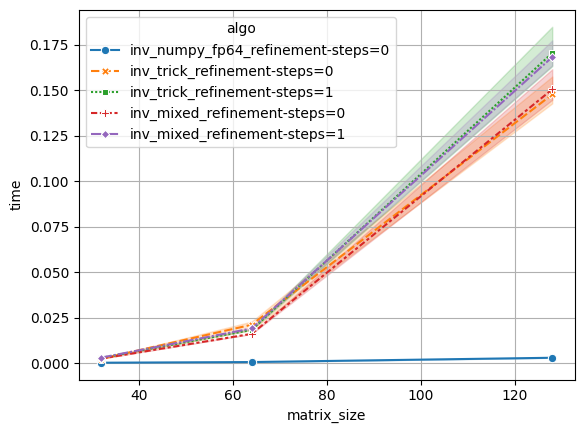

matrix_size,32,64,128
algo,,,
inv_mixed_refinement-steps=0,3.863e-03,6.697e-03,8.420e-03
inv_mixed_refinement-steps=1,3.109e-04,6.839e-04,9.626e-04
inv_numpy_fp64_refinement-steps=0,0.000e+00,0.000e+00,0.000e+00
inv_trick_refinement-steps=0,4.463e-01,nan,nan
inv_trick_refinement-steps=1,2.224e-04,nan,nan


In [ ]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

max_iters = 5
it_ref_steps = 1
#algos = ['inv_ref', 'inv_trick', 'inv_naive', 'inv_rec_unroll_masked', 'inv_rec_unroll']

class AlgTest:
    def __init__(self, algorithm: callable, refinement_steps: int = 0, transpose: bool = False):
        self.algorithm = algorithm
        self.refinement_steps = refinement_steps
        self.name = self.algorithm.__name__ + '_refinement-steps=' + str(self.refinement_steps)
        self.transpose = transpose

if __name__=="__main__":
    print("%")
    print("% dtype: fp16")
    print("% error formula: ||A_inv_true - A_inv_result||_F / ||A_inv_true||_F")
    print("%")

    alg_tests =[
            AlgTest(inv_numpy_fp64, refinement_steps=0, transpose=False),
            AlgTest(inv_trick, refinement_steps=0, transpose=False),
            AlgTest(inv_trick, refinement_steps=1, transpose=False),
            AlgTest(inv_mixed, refinement_steps=0, transpose=False),
            AlgTest(inv_mixed, refinement_steps=1, transpose=False),
        ]

    times_data = {'algo': [], 'matrix_size': [], 'time': []}
    error_data = {'algo': [], 'matrix_size': [], 'error': []}
    for c in N_VALUES:
        print("===============")
        print(f"size = {c}x{c}")
        A = strict_lower(c).astype(INPUT_DTYPE)
        
        A_inv_ref = inv_numpy_fp64(A)

        for alg_test in alg_tests:
            for _ in range(max_iters):
                t = time.time()
                A_res = alg_test.algorithm(A, refinement_steps = alg_test.refinement_steps)
                t = time.time()-t
                times_data['algo'].append(alg_test.name)
                times_data['matrix_size'].append(c)
                times_data['time'].append(t)
            error_data['algo'].append(alg_test.name)
            error_data['matrix_size'].append(c)
            error_data['error'].append(np.linalg.norm(A_res - A_inv_ref, "fro") / np.linalg.norm(A_inv_ref,"fro"))

    # fig, ax = plt.subplots()
    times_df = pd.DataFrame(times_data)
    sns.lineplot(times_df, x='matrix_size', y='time', hue='algo', style='algo', markers=True, errorbar=('ci', 95), err_style='band')
    # plt.yscale('log')
    plt.grid()
    plt.show()

    error_df = pd.DataFrame(error_data)
    pivot_table = error_df.pivot(index='algo', columns='matrix_size', values='error')
    styled_table = pivot_table.style.format('{:.3e}')
    styled_table = styled_table.set_caption('Frobenius norm relative error')
    display(styled_table)
    
